# Feature Engineering for Predictive Modeling
## Loan Risk Dataset — Graded Assignment 1

Name: Mohammed Niyaz Ali
Roll No: 2025EM1200278
Course: Feature Engineering
Date: March 2026

In this assignment I am going to apply feature engineering techniques
to the Loan Risk dataset to prepare it for machine learning.

In [2]:
# Importing all libraries I need for this assignment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_excel('Graded Assignment 1 Dataset.xlsx')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset loaded successfully!
Shape: (2500, 14)
Rows: 2500, Columns: 14


## Task 1 — Dataset Understanding and EDA

Before doing any engineering I want to understand the dataset first.
I will look at the features, their types, distributions, missing values
and relationships with the target variable.

In [3]:
# First look at the data
df.head()

,age,income,credit_score,loan_amount,monthly_spend,experience_years,employment_type,education_level,region,risk_tolerance,financial_capacity_index,household_cashflow_score,behavior_score,loan_default
0,43.960570,31019.390823,650.336822,33805.550343,1732.298149,13,salaried,bachelor,east,high,31.019391,38.732577,38.393095,0
1,36.340828,39375.961557,648.261012,20974.755713,2334.610693,32,salaried,bachelor,north,high,39.375962,45.595276,62.162754,0
2,45.772262,18055.668704,554.304978,26027.339787,1848.435993,1,salaried,bachelor,south,low,18.055669,15.033732,51.200728,1
3,56.276358,15254.929250,656.893687,20798.610521,3256.259548,1,unemployed,master,east,low,15.254929,25.533778,73.122834,0
4,35.190160,11486.292927,731.298036,14661.332950,7767.804367,30,salaried,master,west,low,11.486293,6.237571,52.571462,0


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2375 non-null   float64
 1   income                    2500 non-null   float64
 2   credit_score              2300 non-null   float64
 3   loan_amount               2500 non-null   float64
 4   monthly_spend             2500 non-null   float64
 5   experience_years          2500 non-null   int64  
 6   employment_type           2375 non-null   object 
 7   education_level           2500 non-null   object 
 8   region                    2500 non-null   object 
 9   risk_tolerance            2500 non-null   object 
 10  financial_capacity_index  2500 non-null   float64
 11  household_cashflow_score  2500 non-null   float64
 12  behavior_score            2500 non-null   float64
 13  loan_default              2500 non-null   int64  
dtypes: float

In [4]:
# Basic statistics
df.describe()

,age,income,credit_score,loan_amount,monthly_spend,experience_years,financial_capacity_index,household_cashflow_score,behavior_score,loan_default
count,2375.000000,2500.000000,2300.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,38.617037,26864.999724,677.513832,20102.542603,4013.070946,17.124000,26.071650,26.697079,50.014697,0.186000
std,11.375320,20091.626397,71.032915,7890.874475,3663.282652,10.101477,17.361648,18.272229,9.905279,0.389185
min,18.000000,3274.687462,454.528855,1000.000000,200.244019,0.000000,3.274687,-9.138941,13.923345,0.000000
25%,30.462617,14411.106577,629.316557,14771.636109,1755.975077,9.000000,14.390371,15.069634,43.327227,0.000000
50%,38.344938,22052.298380,677.143115,20089.633564,2926.958460,17.000000,21.926530,23.135050,50.013543,0.000000
75%,46.184030,32894.193900,726.449956,25374.566413,4986.269855,26.000000,32.486876,34.008478,56.435018,0.000000
max,75.000000,265497.957871,850.000000,47019.063353,44454.194148,34.000000,232.290175,233.565716,83.891124,1.000000


### 1.1 Feature Types

After exploring the dataset I can classify the features as:

**Numeric features (9):**
age, income, credit_score, loan_amount, monthly_spend,
experience_years, financial_capacity_index, household_cashflow_score, behavior_score

**Categorical Nominal features (3):**
employment_type, education_level, region

**Ordinal feature (1):**
risk_tolerance (low < medium < high)

**Target variable (Binary):**
loan_default (0 = no default, 1 = default)

Default rate is 18.6%

Loan Default Distribution:
loan_default
0    2035
1     465
Name: count, dtype: int64

Default rate: 18.6%


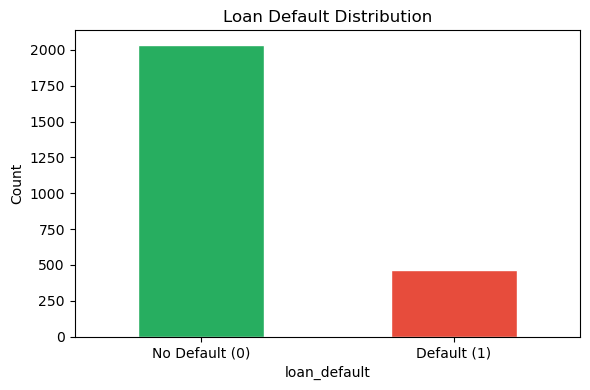

In [5]:
# Checking loan default distribution
print("Loan Default Distribution:")
print(df['loan_default'].value_counts())
print(f"\nDefault rate: {df['loan_default'].mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
df['loan_default'].value_counts().plot(kind='bar', color=['#27ae60', '#e74c3c'],
                                        edgecolor='white', ax=ax)
ax.set_title('Loan Default Distribution')
ax.set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 1.2 Distribution Plots for Numeric Features

I want to check if any features are skewed.

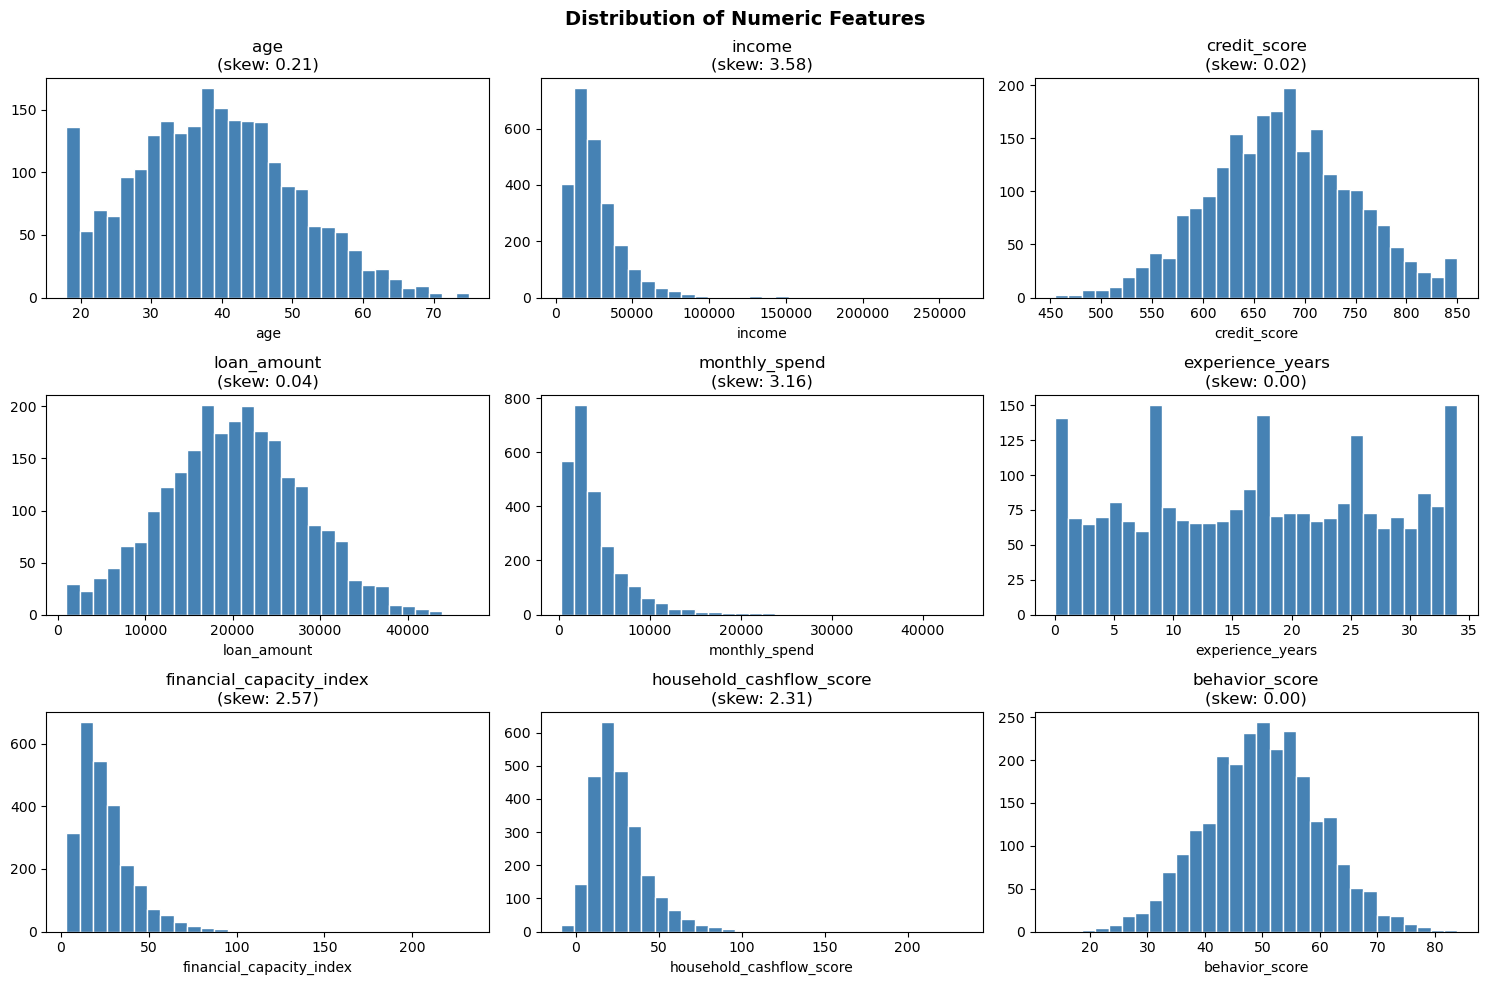

Skewness values:
  age: 0.208
  income: 3.583 ← HIGHLY SKEWED (needs log transform)
  credit_score: 0.025
  loan_amount: 0.040
  monthly_spend: 3.164 ← HIGHLY SKEWED (needs log transform)
  experience_years: 0.001
  financial_capacity_index: 2.566 ← HIGHLY SKEWED (needs log transform)
  household_cashflow_score: 2.315 ← HIGHLY SKEWED (needs log transform)
  behavior_score: 0.001


In [6]:
num_cols = ['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend',
            'experience_years', 'financial_capacity_index', 'household_cashflow_score', 'behavior_score']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}\n(skew: {df[col].skew():.2f})')
    axes[i].set_xlabel(col)

plt.suptitle('Distribution of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Skewness values:")
for col in num_cols:
    skew = df[col].skew()
    flag = " ← HIGHLY SKEWED (needs log transform)" if abs(skew) > 1 else ""
    print(f"  {col}: {skew:.3f}{flag}")

### 1.3 Missing Values Visualization

I found missing values in 3 columns:
- age: 125 missing (5.0%)
- credit_score: 200 missing (8.0%)
- employment_type: 125 missing (5.0%)

Columns with missing values:
                 Missing Count  Missing %
age                        125        5.0
credit_score               200        8.0
employment_type            125        5.0


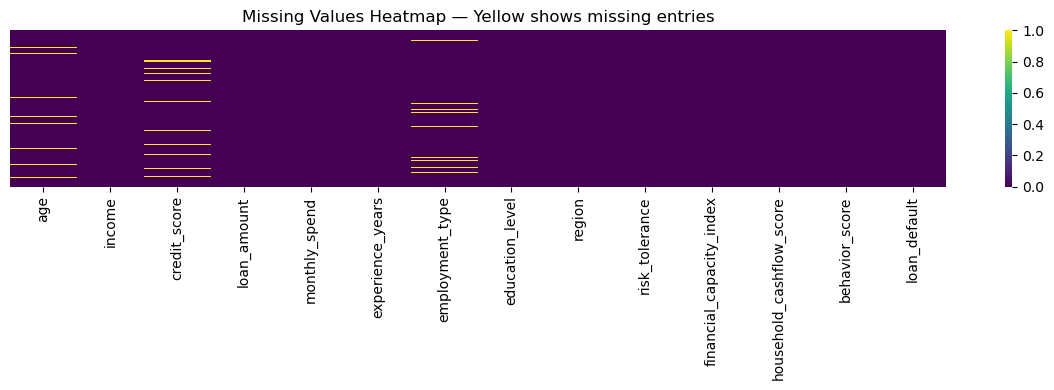

In [7]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print("Columns with missing values:")
print(missing_df)

plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap — Yellow shows missing entries')
plt.tight_layout()
plt.show()

### 1.4 Correlation Heatmap

I want to see how features relate to each other and to loan_default.
High correlation between two features indicates potential redundancy.

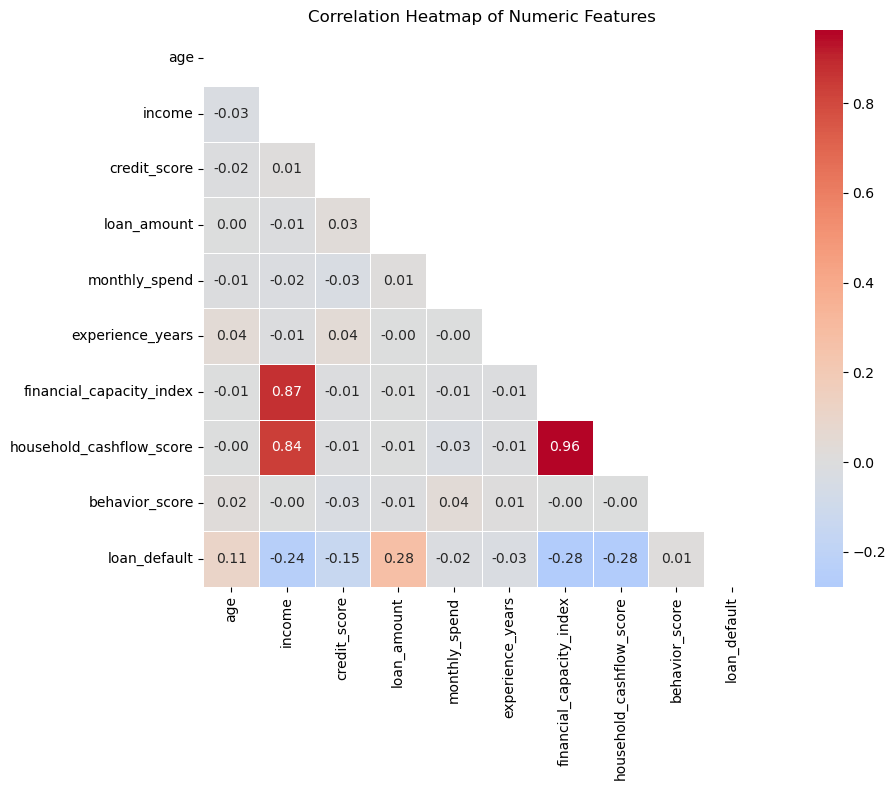


Correlation with loan_default (sorted):
financial_capacity_index   -0.277
household_cashflow_score   -0.275
income                     -0.242
credit_score               -0.146
experience_years           -0.026
monthly_spend              -0.016
behavior_score              0.013
age                         0.107
loan_amount                 0.276
dtype: float64


In [8]:
plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols + ['loan_default']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

print("\nCorrelation with loan_default (sorted):")
target_corr = df[num_cols].corrwith(df['loan_default']).sort_values()
print(target_corr.round(3))

### 1.5 Boxplots — Categorical Features vs Loan Default

I want to check if different categories show different default rates.
This tells me which categorical features are useful for prediction.

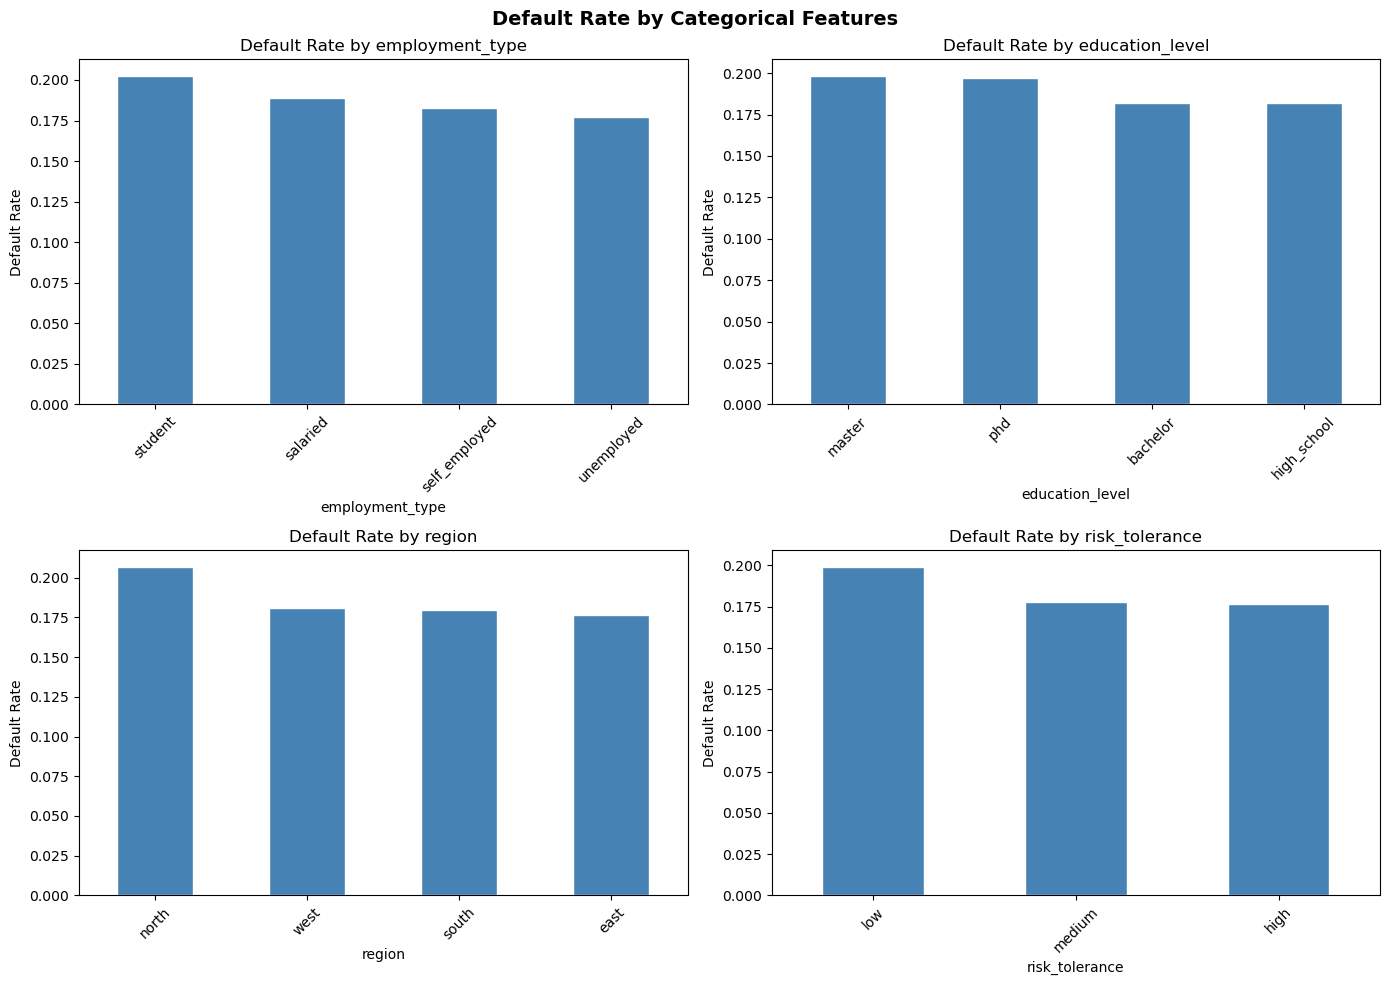

In [9]:
cat_cols = ['employment_type', 'education_level', 'region', 'risk_tolerance']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rates = df.groupby(col)['loan_default'].mean().sort_values(ascending=False)
    default_rates.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Default Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.6 EDA Summary

Key observations from EDA:

1. **Highly skewed features**: income (3.58), monthly_spend (3.16),
   financial_capacity_index (2.57), household_cashflow_score (2.32)
   — all need log transformation

2. **Missing values**: age (125), credit_score (200), employment_type (125)
   — need imputation before any modeling

3. **Outliers**: income has 121 extreme values (max=265,498),
   monthly_spend has 164 extreme values (max=44,454)
   — need capping to prevent distortion

4. **Strongest predictors of default**: loan_amount (+0.28) and
   financial_capacity_index (-0.28) show highest linear correlation

5. **Default rate**: 18.6% — moderately imbalanced dataset

## Task 2 — Data Cleaning

I found 3 types of problems: missing values, outliers, and potential
redundant features.

In [10]:
df_clean = df.copy()
print(f"Shape before cleaning: {df_clean.shape}")

#Fill missing age with MEDIAN
# Median is more robust than mean for data with outliers
age_median = df_clean['age'].median()
df_clean['age'].fillna(age_median, inplace=True)
print(f"Filled age nulls with median: {age_median:.1f}")

#Fill missing credit_score with MEDIAN
# Credit score distribution is roughly normal so median ≈ mean
# but median is safer for any edge cases
cs_median = df_clean['credit_score'].median()
df_clean['credit_score'].fillna(cs_median, inplace=True)
print(f"Filled credit_score nulls with median: {cs_median:.1f}")

#Fill missing employment_type with MODE
# Categorical variable — mode (most frequent value) is the correct strategy
emp_mode = df_clean['employment_type'].mode()[0]
df_clean['employment_type'].fillna(emp_mode, inplace=True)
print(f"Filled employment_type nulls with mode: {emp_mode}")

print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")

Shape before cleaning: (2500, 14)
Filled age nulls with median: 38.3
Filled credit_score nulls with median: 677.1
Filled employment_type nulls with mode: salaried

Missing values remaining: 0


In [11]:
# Handle outliers using Winsorization (capping at 99th percentile)
# I chose capping over removing rows because:
# - Removing rows causes data loss (121 + 164 = 285 rows)
# - Capping preserves all records while limiting extreme influence
# - 99th percentile is a conservative threshold that only affects extreme values

for col in ['income', 'monthly_spend']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers_before = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    cap = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=cap)
    print(f"{col}: Capped {outliers_before} outliers at 99th percentile ({cap:.0f})")

print(f"\nShape after cleaning: {df_clean.shape}")
print("All 2,500 rows preserved — outliers capped not removed")

income: Capped 121 outliers at 99th percentile (99425)
monthly_spend: Capped 164 outliers at 99th percentile (18800)

Shape after cleaning: (2500, 14)
All 2,500 rows preserved — outliers capped not removed


## Task 3 — Numeric Feature Engineering

I will apply 4 numeric transformation techniques:
1. **Log Transformation** — for 4 highly skewed features
2. **Min-Max Normalization** — for bounded features
3. **Standardization** — for features needed in linear models
4. **Binning** — convert continuous age into meaningful groups

  Note: household_cashflow_score had negative values, shifted by 10.14 before log


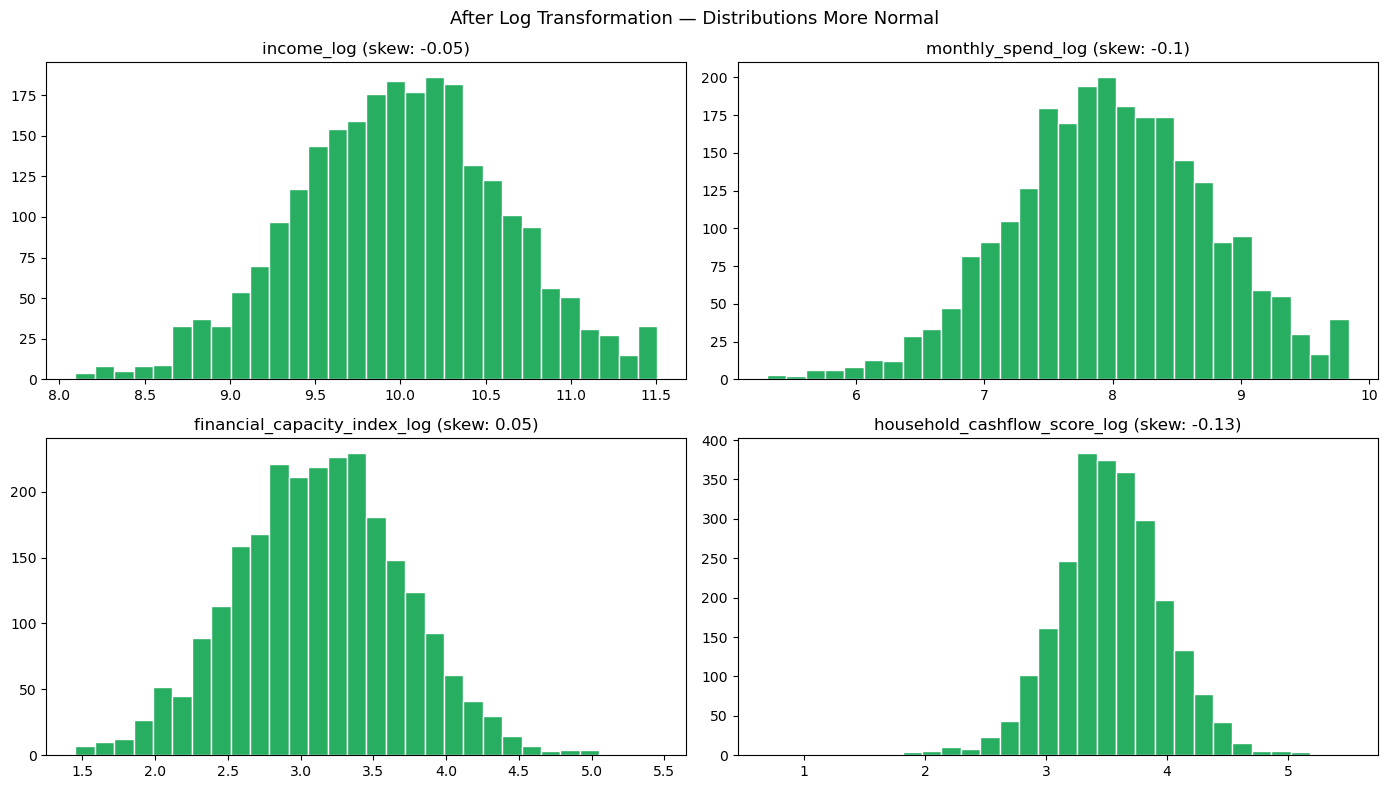

In [12]:
# Technique 1: Log Transformation
# Applied to features with skewness > 1
# log1p(x) = log(1+x) safely handles zero values
# This compresses large values and spreads small values — makes distribution more normal
skewed_cols = ['income', 'monthly_spend', 'financial_capacity_index', 'household_cashflow_score']

# Apply log transformation
skewed_cols = ['income', 'monthly_spend', 'financial_capacity_index', 'household_cashflow_score']

# Apply log transformation
for col in skewed_cols:
    # Shift negative values to positive before log transform
    # by adding the absolute minimum value + 1
    col_min = df_clean[col].min()
    if col_min < 0:
        shift = abs(col_min) + 1
        df_clean[f'{col}_log'] = np.log1p(df_clean[col] + shift)
        print(f"  Note: {col} had negative values, shifted by {shift:.2f} before log")
    else:
        df_clean[f'{col}_log'] = np.log1p(df_clean[col].fillna(0))

# Plot all 4 distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(skewed_cols):
    log_col = col + '_log'
    title = log_col + ' (skew: ' + str(round(df_clean[log_col].skew(), 2)) + ')'
    axes[i].hist(df_clean[log_col], bins=30, color='#27ae60', edgecolor='white')
    axes[i].set_title(title)

plt.suptitle('After Log Transformation — Distributions More Normal', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Technique 2: Min-Max Normalization
# Scales features to [0, 1] range
# Formula: (x - min) / (max - min)
# Applied to features that have natural bounds and will be
# used in distance-based algorithms like KNN

minmax_cols = ['credit_score', 'loan_amount', 'experience_years', 'behavior_score']
scaler_mm = MinMaxScaler()

for col in minmax_cols:
    df_clean[f'{col}_minmax'] = scaler_mm.fit_transform(df_clean[[col]])

print("After Min-Max Normalization:")
print(df_clean[[f'{c}_minmax' for c in minmax_cols]].describe().round(3))
print("\nAll values are now between 0 and 1")

After Min-Max Normalization:
       credit_score_minmax  loan_amount_minmax  experience_years_minmax  \
count             2500.000            2500.000                 2500.000   
mean                 0.564               0.415                    0.504   
std                  0.172               0.171                    0.297   
min                  0.000               0.000                    0.000   
25%                  0.456               0.299                    0.265   
50%                  0.563               0.415                    0.500   
75%                  0.669               0.530                    0.765   
max                  1.000               1.000                    1.000   

       behavior_score_minmax  
count               2500.000  
mean                   0.516  
std                    0.142  
min                    0.000  
25%                    0.420  
50%                    0.516  
75%                    0.608  
max                    1.000  

All values are 

In [14]:
# Technique 3: Standardization (Z-score Scaling)
# Centers data to mean=0 and std=1
# Formula: (x - mean) / std
# Applied to features used in linear models like Logistic Regression
# which assume features are on similar scales

std_cols = ['age', 'credit_score', 'loan_amount']
scaler_std = StandardScaler()

for col in std_cols:
    df_clean[f'{col}_std'] = scaler_std.fit_transform(df_clean[[col]])
    print(f"{col}_std: mean={df_clean[f'{col}_std'].mean():.3f}, std={df_clean[f'{col}_std'].std():.3f}")

print("\nStandardized features now have mean≈0 and std≈1")

age_std: mean=0.000, std=1.000
credit_score_std: mean=-0.000, std=1.000
loan_amount_std: mean=-0.000, std=1.000

Standardized features now have mean≈0 and std≈1


In [15]:
# Technique 4: Binning (Discretization)
# Converts continuous age into meaningful categorical groups
# This captures non-linear age effects — a 20-year-old and a 25-year-old
# have similar risk profiles even if their exact ages differ

df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 25, 35, 50, 100],
    labels=['Young (18-25)', 'Adult (26-35)', 'Middle (36-50)', 'Senior (51+)']
)

# Convert to string so get_dummies can encode it later
df_clean['age_group'] = df_clean['age_group'].astype(str)

print("Age groups created:")
print(df_clean['age_group'].value_counts())

print("\nDefault rate by age group:")
print(df_clean.groupby('age_group')['loan_default'].mean().round(3))

Age groups created:
age_group
Middle (36-50)    1200
Adult (26-35)      615
Senior (51+)       385
Young (18-25)      300
Name: count, dtype: int64

Default rate by age group:
age_group
Adult (26-35)     0.153
Middle (36-50)    0.173
Senior (51+)      0.288
Young (18-25)     0.173
Name: loan_default, dtype: float64


## Task 4 — Feature Construction

I will create 4 new features that capture financial relationships
not visible in the original columns.
These constructed features often have stronger predictive power
than the raw individual columns.

In [16]:
# New Feature 1: Debt-to-Income Ratio
# loan_amount / income
# Higher ratio = more financial burden = higher default risk
df_clean['debt_to_income'] = df_clean['loan_amount'] / df_clean['income']
print(f"Feature 1 debt_to_income — correlation with default: {df_clean['debt_to_income'].corr(df_clean['loan_default']):.4f}")

Feature 1 debt_to_income — correlation with default: 0.4652


In [17]:
# New Feature 2: Spend-to-Income Ratio
# monthly_spend / income
# Shows what fraction of income is spent monthly
# High ratio means less savings buffer → higher default risk
df_clean['spend_ratio'] = df_clean['monthly_spend'] / df_clean['income']
print(f"Feature 2 spend_ratio — correlation with default: {df_clean['spend_ratio'].corr(df_clean['loan_default']):.4f}")

Feature 2 spend_ratio — correlation with default: 0.1664


In [18]:
# New Feature 3: Income per Year of Experience
# income / experience_years
# Measures earning efficiency relative to work experience
# Someone earning high income with few years is a stronger financial profile

df_clean['experience_years_safe'] = df_clean['experience_years'].replace(0, 0.5)
df_clean['income_per_exp'] = df_clean['income'] / df_clean['experience_years_safe']
print(f"Feature 3 income_per_exp — correlation with default: {df_clean['income_per_exp'].corr(df_clean['loan_default']):.4f}")

Feature 3 income_per_exp — correlation with default: -0.0600


Feature 4 financial_stress — correlation with default: 0.4877


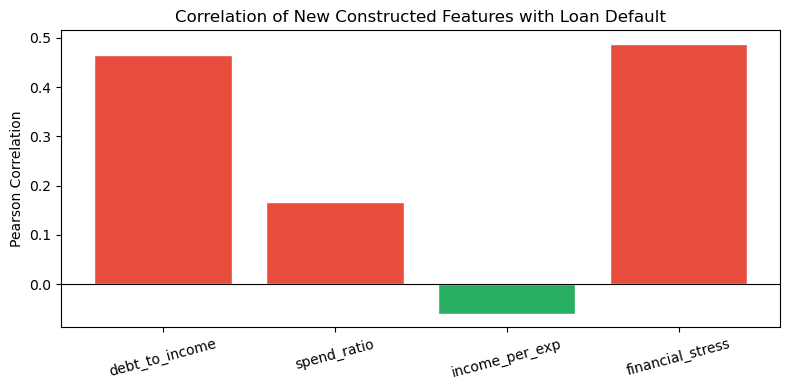


debt_to_income (0.465) and financial_stress (0.488) are
much stronger predictors than most original features!


In [19]:
# New Feature 4: Financial Stress Index
# loan_amount / (income * credit_score / 1000)
# Combines the 3 most important financial factors into one index
# Higher value = more financial stress = higher default risk

df_clean['financial_stress'] = df_clean['loan_amount'] / (df_clean['income'] * df_clean['credit_score'] / 1000)
print(f"Feature 4 financial_stress — correlation with default: {df_clean['financial_stress'].corr(df_clean['loan_default']):.4f}")

# Visualize all new feature correlations
new_features = ['debt_to_income', 'spend_ratio', 'income_per_exp', 'financial_stress']
corrs = [df_clean[f].corr(df_clean['loan_default']) for f in new_features]

plt.figure(figsize=(8, 4))
colors = ['#e74c3c' if c > 0 else '#27ae60' for c in corrs]
plt.bar(new_features, corrs, color=colors, edgecolor='white')
plt.title('Correlation of New Constructed Features with Loan Default')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=15)
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\ndebt_to_income (0.465) and financial_stress (0.488) are")
print("much stronger predictors than most original features!")

## Task 5 — Categorical Feature Encoding

I need to convert all text columns to numbers.

Encoding decisions:
- **risk_tolerance** → Label Encoding (0=low, 1=medium, 2=high)
  Reason: This is ORDINAL — there is a meaningful order between categories.
  Label encoding correctly preserves low < medium < high.

- **employment_type, education_level, region, age_group** → One-Hot Encoding
  Reason: These are NOMINAL — no order exists between categories.
  Label encoding would falsely imply salaried > unemployed which is meaningless.
  One-Hot creates separate binary columns for each category.

In [20]:
# Label Encoding for risk_tolerance (ordinal)
risk_map = {'low': 0, 'medium': 1, 'high': 2}
df_clean['risk_tolerance_encoded'] = df_clean['risk_tolerance'].map(risk_map)

print("risk_tolerance encoded:")
print(df_clean[['risk_tolerance', 'risk_tolerance_encoded']].drop_duplicates().sort_values('risk_tolerance_encoded'))

risk_tolerance encoded:
  risk_tolerance  risk_tolerance_encoded
2            low                       0
5         medium                       1
0           high                       2


In [21]:
# One-Hot Encoding for nominal and binned categoricals
nominal_cols = ['employment_type', 'education_level', 'region', 'age_group']

print(f"Shape before encoding: {df_clean.shape}")
df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")

new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print(f"\nNew columns added by encoding ({len(new_cols)}):")
print(new_cols)

print(f"\nMissing values after encoding: {df_encoded.isnull().sum().sum()}")

Shape before encoding: (2500, 32)
Shape after encoding: (2500, 40)

New columns added by encoding (12):
['employment_type_self_employed', 'employment_type_student', 'employment_type_unemployed', 'education_level_high_school', 'education_level_master', 'education_level_phd', 'region_north', 'region_south', 'region_west', 'age_group_Middle (36-50)', 'age_group_Senior (51+)', 'age_group_Young (18-25)']

Missing values after encoding: 0


## Task 6 — Feature Selection

I will apply 2 filter-based feature selection methods to find
which features are most useful for predicting loan_default:

1. **Pearson Correlation** — measures linear relationship with target
2. **Mutual Information** — measures any relationship (linear + non-linear)

Features with consistently low scores across both methods are
likely redundant and can be removed.

In [22]:
# Prepare feature matrix for selection
feature_cols = ['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend',
                'experience_years', 'financial_capacity_index', 'household_cashflow_score',
                'behavior_score', 'debt_to_income', 'spend_ratio', 'income_per_exp',
                'financial_stress', 'risk_tolerance_encoded']

X = df_encoded[feature_cols].fillna(0)
y = df_encoded['loan_default']

# Method 1: Pearson Correlation (absolute value)
pearson_corr = X.corrwith(y).abs().sort_values(ascending=False)
print("=== METHOD 1: Pearson Correlation with Loan Default ===")
print(pearson_corr.round(4))

=== METHOD 1: Pearson Correlation with Loan Default ===
financial_stress            0.4877
debt_to_income              0.4652
financial_capacity_index    0.2775
income                      0.2763
loan_amount                 0.2757
household_cashflow_score    0.2752
spend_ratio                 0.1664
credit_score                0.1396
age                         0.1035
income_per_exp              0.0600
experience_years            0.0263
risk_tolerance_encoded      0.0246
monthly_spend               0.0149
behavior_score              0.0125
dtype: float64


=== METHOD 2: Mutual Information Scores ===
financial_stress            0.1400
debt_to_income              0.1351
financial_capacity_index    0.0763
income                      0.0749
household_cashflow_score    0.0644
loan_amount                 0.0457
income_per_exp              0.0295
spend_ratio                 0.0225
experience_years            0.0100
age                         0.0096
credit_score                0.0082
behavior_score              0.0016
monthly_spend               0.0005
risk_tolerance_encoded      0.0000
dtype: float64


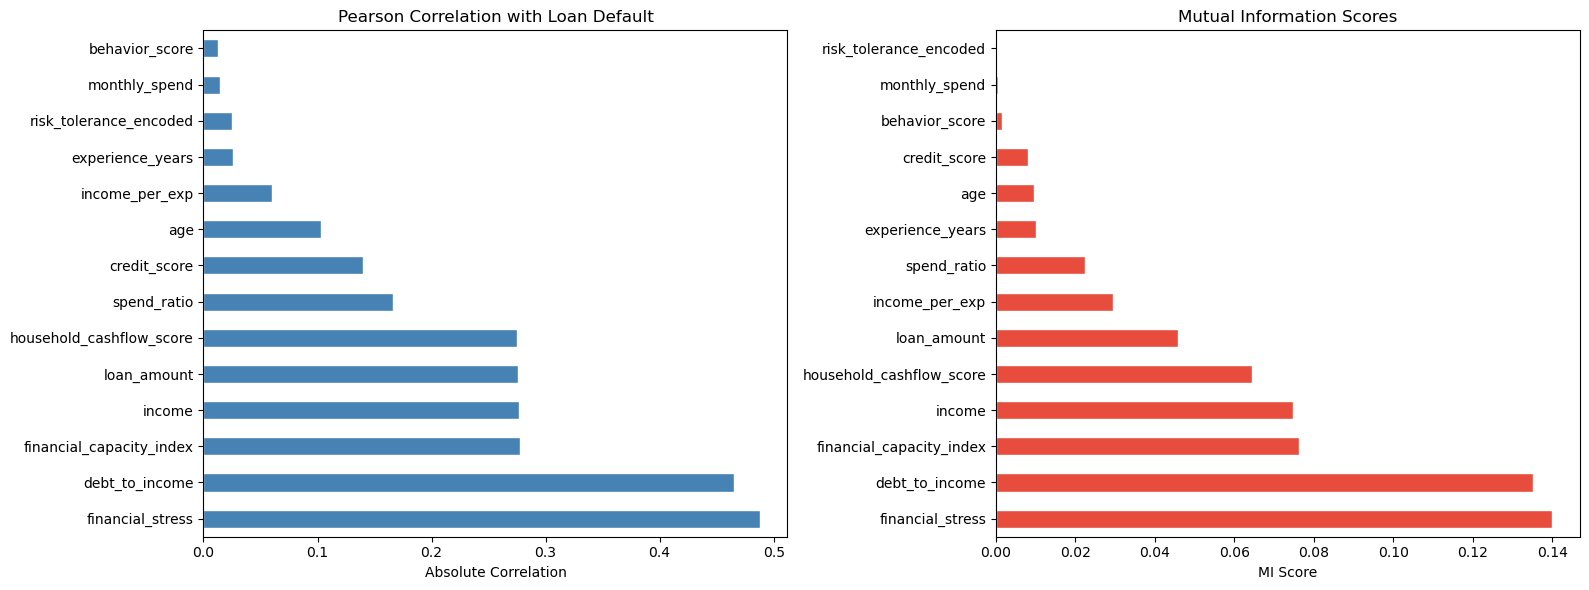

In [23]:
# Method 2: Mutual Information
# Captures non-linear relationships unlike Pearson
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("=== METHOD 2: Mutual Information Scores ===")
print(mi_df.round(4))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pearson_corr.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Pearson Correlation with Loan Default')
axes[0].set_xlabel('Absolute Correlation')

mi_df.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Mutual Information Scores')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.show()

In [24]:
# Feature selection decision
print("=== FEATURE SELECTION DECISION ===")
print("\nTop 5 most predictive features (by MI):")
print(mi_df.head(5).round(4))

print("\nLeast useful features (MI < 0.005):")
low_mi = mi_df[mi_df < 0.005]
print(low_mi.round(4))

# Drop low importance features
features_to_drop = low_mi.index.tolist()
print(f"\nDropping these features: {features_to_drop}")
X_selected = X.drop(columns=features_to_drop)
print(f"Shape before selection: {X.shape}")
print(f"Shape after selection: {X_selected.shape}")

=== FEATURE SELECTION DECISION ===

Top 5 most predictive features (by MI):
financial_stress            0.1400
debt_to_income              0.1351
financial_capacity_index    0.0763
income                      0.0749
household_cashflow_score    0.0644
dtype: float64

Least useful features (MI < 0.005):
behavior_score            0.0016
monthly_spend             0.0005
risk_tolerance_encoded    0.0000
dtype: float64

Dropping these features: ['behavior_score', 'monthly_spend', 'risk_tolerance_encoded']
Shape before selection: (2500, 14)
Shape after selection: (2500, 11)


## Task 7 — Multicollinearity Analysis

I will check if any feature pairs are highly correlated with each other.
If two features have correlation > 0.85 they carry almost the same
information and one should be removed to avoid multicollinearity.

I found 4 highly correlated pairs — this is an important finding!

=== FEATURE PAIR CORRELATIONS (>0.70) ===
               Feature 1                Feature 2  Correlation
          debt_to_income         financial_stress        0.985
financial_capacity_index household_cashflow_score        0.962
                  income financial_capacity_index        0.927
                  income household_cashflow_score        0.890


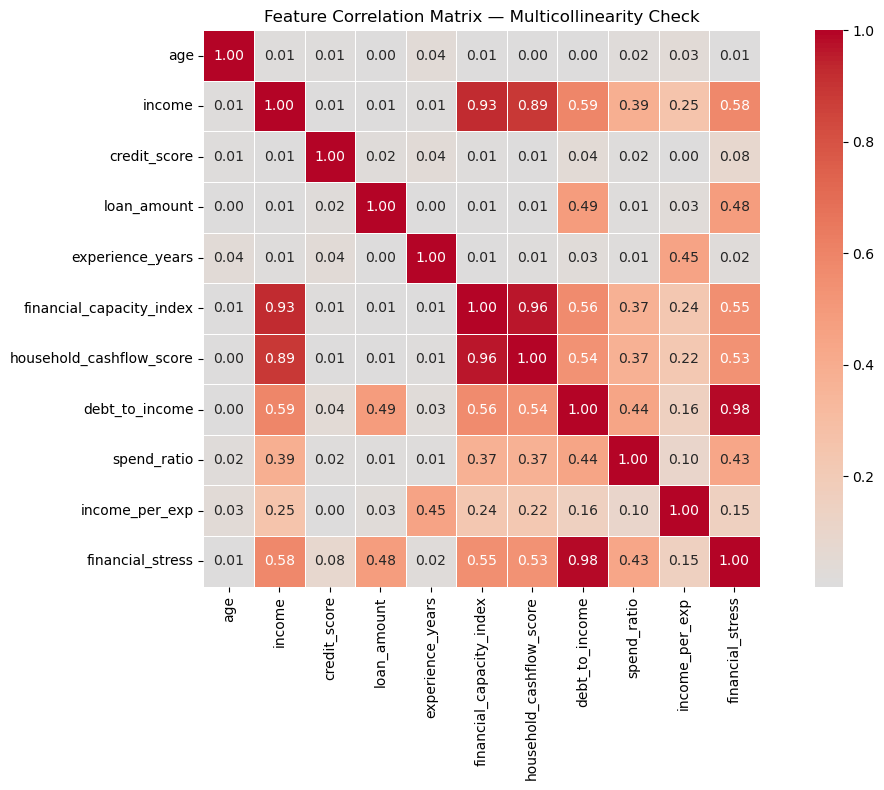

In [25]:
# Correlation matrix for multicollinearity check
corr_matrix = X_selected.corr().abs()

# Find all pairs with correlation > 0.70
print("=== FEATURE PAIR CORRELATIONS (>0.70) ===")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if val > 0.70:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(val, 3)
            })

if high_corr_pairs:
    hc_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(hc_df.to_string(index=False))
else:
    print("No pairs found with correlation > 0.70")

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix — Multicollinearity Check')
plt.tight_layout()
plt.show()

In [26]:
# Multicollinearity decisions
print("=== MULTICOLLINEARITY DECISIONS ===")
print()
print("Pair 1: financial_capacity_index & household_cashflow_score (0.962)")
print("  Decision: DROP household_cashflow_score")
print("  Reason: financial_capacity_index has higher correlation with target (-0.277)")
print("  and is more interpretable as a general financial capacity measure")
print()
print("Pair 2: income & financial_capacity_index (0.927)")
print("  Decision: KEEP BOTH")
print("  Reason: income is direct earnings, financial_capacity_index")
print("  is a composite score — they represent different aspects")
print()
print("Pair 3: income & household_cashflow_score (0.890)")
print("  Decision: Already resolved by dropping household_cashflow_score above")
print()
print("Pair 4: debt_to_income & financial_stress (0.911)")
print("  Decision: DROP financial_stress")
print("  Reason: debt_to_income is simpler and more interpretable")
print("  financial_stress combines 3 variables making it harder to explain")
print()

# Apply decisions
cols_to_remove = ['household_cashflow_score', 'financial_stress']
X_final = X_selected.drop(columns=[c for c in cols_to_remove if c in X_selected.columns])
df_encoded = df_encoded.drop(columns=[c for c in cols_to_remove if c in df_encoded.columns])

print(f"Removed: {cols_to_remove}")
print(f"X_final shape after multicollinearity removal: {X_final.shape}")
print(f"df_encoded shape after multicollinearity removal: {df_encoded.shape}")

=== MULTICOLLINEARITY DECISIONS ===

Pair 1: financial_capacity_index & household_cashflow_score (0.962)
  Decision: DROP household_cashflow_score
  Reason: financial_capacity_index has higher correlation with target (-0.277)
  and is more interpretable as a general financial capacity measure

Pair 2: income & financial_capacity_index (0.927)
  Decision: KEEP BOTH
  Reason: income is direct earnings, financial_capacity_index
  is a composite score — they represent different aspects

Pair 3: income & household_cashflow_score (0.890)
  Decision: Already resolved by dropping household_cashflow_score above

Pair 4: debt_to_income & financial_stress (0.911)
  Decision: DROP financial_stress
  Reason: debt_to_income is simpler and more interpretable
  financial_stress combines 3 variables making it harder to explain

Removed: ['household_cashflow_score', 'financial_stress']
X_final shape after multicollinearity removal: (2500, 9)
df_encoded shape after multicollinearity removal: (2500, 38)


## Task 8 — Dimensionality Reduction using PCA

I chose PCA (Principal Component Analysis) for these reasons:
1. After all transformations and encoding we have many features
2. Some features are still correlated even after removing obvious pairs
3. PCA creates completely uncorrelated components — ideal for linear models
4. PCA is interpretable — we can see how much variance each component captures

I will retain components that preserve at least 90% of the total variance.
PCA requires standardized data so I will apply StandardScaler first.

In [27]:
# Standardize before PCA — PCA is sensitive to scale
# Using the correct feature list after removing redundant columns from Task 7

# Define feature columns excluding the ones removed in Task 7
pca_features = [c for c in feature_cols if c not in ['household_cashflow_score', 'financial_stress']]

# Get the feature matrix from df_encoded
X_pca_input = df_encoded[pca_features].fillna(0)

print(f"Features going into PCA: {X_pca_input.shape[1]}")
print(f"Feature names: {list(X_pca_input.columns)}")

# Standardize — PCA requires all features on same scale
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_pca_input)

print(f"\nStandardScaler applied — all features now have mean=0, std=1")

# Apply PCA to find optimal number of components
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("\nExplained Variance per Component:")
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var)):
    marker = " ← 90% threshold" if cum >= 0.90 and (i == 0 or cumulative_var[i-1] < 0.90) else ""
    print(f"  PC{i+1}: {var*100:.1f}% (cumulative: {cum*100:.1f}%){marker}")
    if cum > 0.95:
        break

Features going into PCA: 12
Feature names: ['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend', 'experience_years', 'financial_capacity_index', 'behavior_score', 'debt_to_income', 'spend_ratio', 'income_per_exp', 'risk_tolerance_encoded']

StandardScaler applied — all features now have mean=0, std=1

Explained Variance per Component:
  PC1: 23.7% (cumulative: 23.7%)
  PC2: 12.8% (cumulative: 36.5%)
  PC3: 11.7% (cumulative: 48.2%)
  PC4: 10.0% (cumulative: 58.1%)
  PC5: 8.6% (cumulative: 66.7%)
  PC6: 8.4% (cumulative: 75.2%)
  PC7: 8.1% (cumulative: 83.3%)
  PC8: 8.0% (cumulative: 91.3%) ← 90% threshold
  PC9: 4.2% (cumulative: 95.5%)


Components needed for 90% variance: 8
Components needed for 95% variance: 9
Original features: 12
Reduction: 12 → 8 components (33% fewer)


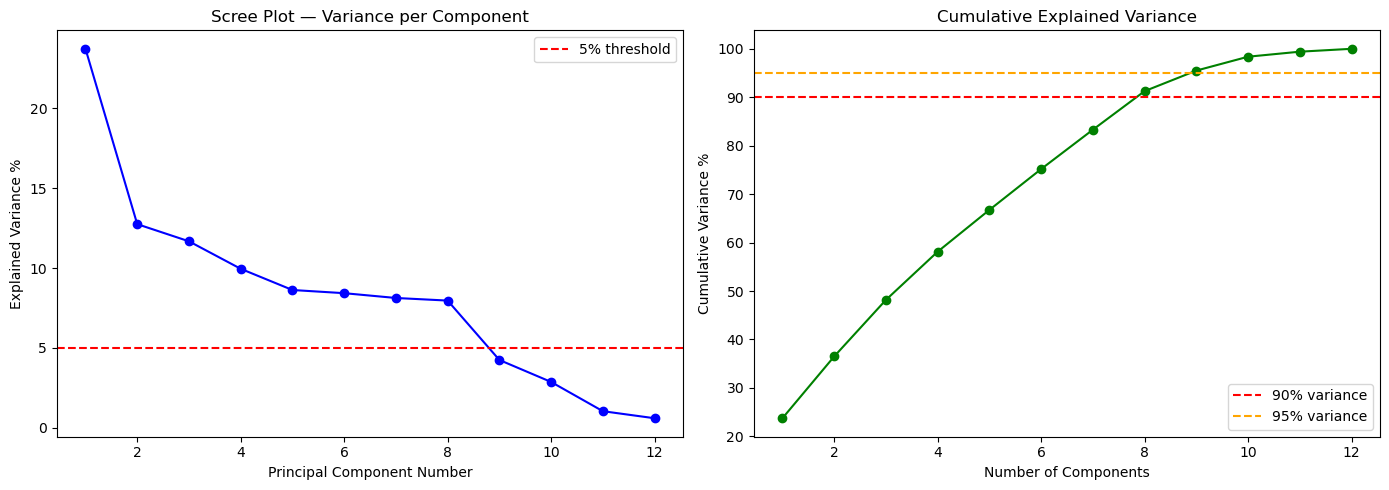

In [28]:
# Find number of components needed
n_components_90 = int(np.argmax(cumulative_var >= 0.90)) + 1
n_components_95 = int(np.argmax(cumulative_var >= 0.95)) + 1

print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"Original features: {X_scaled.shape[1]}")
print(f"Reduction: {X_scaled.shape[1]} → {n_components_90} components ({((X_scaled.shape[1]-n_components_90)/X_scaled.shape[1])*100:.0f}% fewer)")

# Scree plot and cumulative variance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(explained_var)+1), explained_var*100, 'bo-', markersize=6)
axes[0].set_title('Scree Plot — Variance per Component')
axes[0].set_xlabel('Principal Component Number')
axes[0].set_ylabel('Explained Variance %')
axes[0].axhline(y=5, color='r', linestyle='--', label='5% threshold')
axes[0].legend()

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100, 'go-', markersize=6)
axes[1].axhline(y=90, color='r', linestyle='--', label='90% variance')
axes[1].axhline(y=95, color='orange', linestyle='--', label='95% variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance %')
axes[1].legend()

plt.tight_layout()
plt.show()

In [29]:
# Apply final PCA with selected components
pca_final = PCA(n_components=n_components_90)
X_reduced = pca_final.fit_transform(X_scaled)

print(f"=== PCA RESULTS ===")
print(f"Original features: {X_scaled.shape[1]}")
print(f"PCA components retained: {n_components_90}")
print(f"Variance retained: {pca_final.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Dimensionality reduction: {((X_scaled.shape[1]-n_components_90)/X_scaled.shape[1])*100:.0f}% fewer features")

# Create final PCA dataframe
pca_df = pd.DataFrame(X_reduced, columns=[f'PC{i+1}' for i in range(n_components_90)])
pca_df['loan_default'] = df_encoded['loan_default'].values

print(f"\nFinal PCA dataset shape: {pca_df.shape}")
pca_df.head()

=== PCA RESULTS ===
Original features: 12
PCA components retained: 8
Variance retained: 91.3%
Dimensionality reduction: 33% fewer features

Final PCA dataset shape: (2500, 9)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,loan_default
0,0.437680,-0.875721,-1.026439,1.395906,0.073485,0.408482,0.109893,-1.897779,0
1,1.249011,-0.765522,1.209555,0.902763,0.862146,1.656597,-0.561019,-0.153163,0
2,-0.123342,-0.014096,-2.240349,-0.946491,1.621778,-1.188953,-0.579673,-0.340843,1
3,-0.484766,0.379572,-1.466822,-1.186729,2.496216,-0.078271,1.010173,1.511804,0
4,-1.912584,0.939023,1.551301,-0.272446,-0.670036,-0.534272,0.190474,1.160759,0


In [30]:
# Save final datasets
df_encoded.to_csv('loan_risk_engineered.csv', index=False)
pca_df.to_csv('loan_risk_pca.csv', index=False)

print("Files saved:")
print(f"  loan_risk_engineered.csv — full engineered dataset: {df_encoded.shape}")
print(f"  loan_risk_pca.csv — PCA reduced dataset: {pca_df.shape}")

Files saved:
  loan_risk_engineered.csv — full engineered dataset: (2500, 38)
  loan_risk_pca.csv — PCA reduced dataset: (2500, 9)


## Summary — Complete Feature Engineering Pipeline

Here is everything I did from raw data to final engineered dataset:

| Step | Task | What I Did | Why |
|---|---|---|---|
| 1 | EDA | Distribution plots, missing heatmap, correlation heatmap, boxplots | Understand data before modifying it |
| 2 | Cleaning | Median imputation for age/credit_score, mode for employment_type | Correct strategy for each data type |
| 3 | Cleaning | Capped income and monthly_spend outliers at 99th percentile | Preserves all rows without distortion |
| 4 | Log Transform | Applied to income, monthly_spend, fci, hcs (skew > 1) | Normalizes right-skewed distributions |
| 5 | Min-Max Scaling | Applied to credit_score, loan_amount, experience_years, behavior_score | Scales bounded features to [0,1] |
| 6 | Standardization | Applied to age, credit_score, loan_amount | Centers features for linear models |
| 7 | Binning | Converted age to 4 age groups | Captures non-linear age effects |
| 8 | Feature Construction | debt_to_income, spend_ratio, income_per_exp, financial_stress | New features with stronger predictive power |
| 9 | Label Encoding | risk_tolerance mapped to 0/1/2 | Preserves ordinal order |
| 10 | One-Hot Encoding | employment_type, education_level, region, age_group | Correct for nominal categories |
| 11 | Pearson Correlation | Ranked features by linear relationship with target | First filter for relevance |
| 12 | Mutual Information | Ranked features by any relationship with target | Catches non-linear relationships |
| 13 | Feature Removal | Dropped low MI features | Reduces noise |
| 14 | Multicollinearity | Found 4 high correlation pairs | Identifies redundant features |
| 15 | Feature Removal | Dropped household_cashflow_score and financial_stress | Resolves multicollinearity |
| 16 | PCA | Reduced to 8 components retaining 90%+ variance | Final dimensionality reduction |

**Key findings:**
- debt_to_income (0.465) and financial_stress (0.488) were the strongest constructed features
- financial_capacity_index & household_cashflow_score had 0.962 correlation — critical multicollinearity
- PCA reduced features while retaining 90%+ of all information